# **LIMPEZA DOS DADOS DO TITANIC**



*   Dataset do titanic:

    -[Titanic](https://www.kaggle.com/competitions/titanic/overview)



*   Variáveis
    
    - Survived:	Sobrevivência	0 = Não, 1 = Sim
    - Pclass:	Classe de bilhete	(1 = 1º, 2 = 2º, 3 = 3º)
    - Sex:	Genêro
    - Age:	Idade em anos
    - Sibsp: N° de irmãos / cônjuges a bordo do Titanic
    - Parch: N° de pais / filhos a bordo do Titanic
    - Ticket:	Número do bilhete
    - Fare:	Tarifa de passageiros
    - Cabin:	Número da cabine
    - Embarked:	Porto de Embarque	(C = Cherbourg, Q = Queenstown, S = Southampton)


      
    






In [308]:
# Importando o pandas
import pandas as pd

In [309]:
# Importando a base do titanic
titanic = pd.read_csv('/content/drive/MyDrive/train.csv')

In [310]:
# Visualizando a base
titanic.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [311]:
# Formato
titanic.shape

(891, 12)

In [312]:
# Informações da base (tipo da coluna, linhas não nulas, ...)
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [313]:
# Resumo estatístico
titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [314]:
# Cardinalidade (quantidade de valores vazios em cada uma das colunas)
titanic.nunique()

,0
PassengerId,891
Survived,2
Pclass,3
Name,891
Sex,2
Age,88
SibSp,7
Parch,7
Ticket,681
Fare,248


In [315]:
# Visualizando os valores vazios
titanic.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


# Verificando os valores vazios
 - Embarque:

In [316]:
# Verificando os registros com embarque vazio
titanic[titanic['Embarked'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


In [317]:
# Atualizando o valor para as 2 linhas
titanic.loc[61, 'Embarked'] = 'S'
titanic.loc[829, 'Embarked'] = 'S'

  - Analisando a idade

In [318]:
# Verificando valores nulos na idade
titanic[titanic['Age'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
859,860,0,3,"Razi, Mr. Raihed",male,NaN,0,0,2629,7.2292,NaN,C
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,NaN,S
868,869,0,3,"van Melkebeke, Mr. Philemon",male,NaN,0,0,345777,9.5000,NaN,S
878,879,0,3,"Laleff, Mr. Kristo",male,NaN,0,0,349217,7.8958,NaN,S


In [319]:
# Verificando o describe para a idade
titanic.Age.describe()

,Age
count,714.000000
mean,29.699118
std,14.526497
min,0.420000
25%,20.125000
50%,28.000000
75%,38.000000
max,80.000000


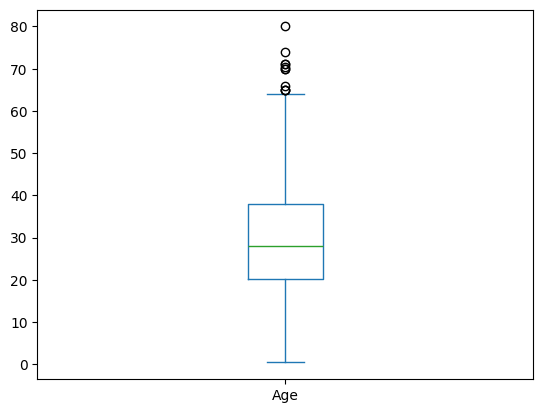

In [320]:
# Visualizando graficamente no boxplot
titanic.Age.plot.box();

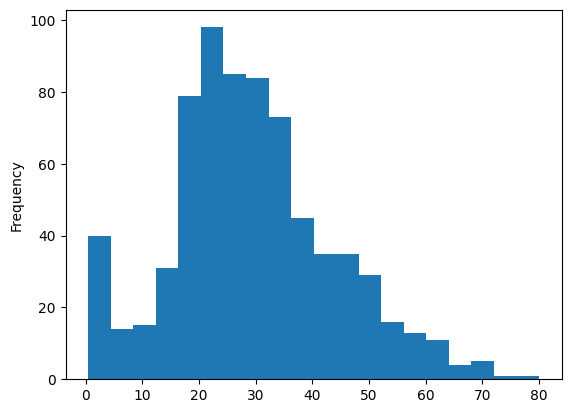

In [321]:
# Histrograma
titanic.Age.plot.hist(bins=20);

In [322]:
# Uma opção então, seria usar a mediana, ou a média das idades
titanic.Age.median()

28.0

In [323]:
# Ou podemos, por exemplo, tirar a média de idade por alguns grupos como Pclass
titanic.groupby('Pclass')['Age'].median()

,Age
Pclass,
1,37.0
2,29.0
3,24.0


In [324]:
# Podemos adicionar o gênero
titanic.groupby(['Pclass', 'Sex'])['Age'].median()


Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: Age, dtype: float64

  - Para criar uma nova coluna com esses valores, irei utilizar o [transform](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.transform.html) do pandas

In [325]:
# Criando uma nova coluna das idades
titanic['Age_Check1'] = titanic.groupby(['Pclass', 'Sex'])['Age'].transform('median')

In [326]:
# Visualizando a base
titanic.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_Check1
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,25.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,35.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,21.5


In [327]:
# Utilizar esse valor diretamente no fillna, ou seja, retornando a idade quando a idade não for vazia. Quando for vazia, retorna a mediana do groupby
titanic['Age_Check2'] = titanic.Age.fillna(titanic.groupby(['Pclass', 'Sex'])['Age'].transform('median'))

In [328]:
# Visualizando novamente a base
titanic.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_Check1,Age_Check2
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,25.0,22.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,35.0,38.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,21.5,26.0


In [329]:
# Então, irei usar esse valor na idade
titanic['Age'] = titanic.Age.fillna(titanic.groupby(['Pclass', 'Sex'])['Age'].transform('median'))

In [330]:
# Apagando as duas colunas de análise (suporte)
titanic = titanic.drop(['Age_Check1', 'Age_Check2'], axis=1)

In [331]:
# Verificando novamente os valores nulos
titanic.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


  - Analisando a cabine

In [332]:
# Verificando as informações em cabine
titanic.Cabin.value_counts()

,count
Cabin,
G6,4
C23 C25 C27,4
B96 B98,4
F2,3
D,3
...,...
E17,1
A24,1
C50,1


In [333]:
# Devido a essa informação não trazer muito resultado, irei elimina-la da base
titanic = titanic.drop('Cabin', axis=1)

  - Analisando nome

In [334]:
# As informações de nome também não serão necessárias
titanic = titanic.drop('Name', axis=1)

  - Analisando a base final

In [335]:
# Base
titanic.head(3)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,S


In [336]:
# Cardinalidade
titanic.nunique()

,0
PassengerId,891
Survived,2
Pclass,3
Sex,2
Age,89
SibSp,7
Parch,7
Ticket,681
Fare,248
Embarked,3


  - Irei eliminar diretamente as informações que não irão ajudar no nosso modelo, como PassengerId e Ticket

In [337]:
# Removendo as colunas PassengerId e Ticket
titanic = titanic.drop(['PassengerId', 'Ticket'], axis=1)

In [338]:
# Base final
titanic.head(3)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S


In [339]:
# Visualizando as informações tratadas
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


# Encoding (Transformação de Texto para Número)

In [340]:
# Transformando 'Sex' em binário: female=0, male=1 (Label Encoding)
titanic['Sex'] = titanic['Sex'].map({'female': 0, 'male': 1})

In [341]:
# Transformando 'Embarked' em colunas separadas (One-Hot Encoding)
# Isso cria as colunas Embarked_Q e Embarked_S (a Embarked_C fica implícita como base) [cite: 15]
titanic = pd.get_dummies(titanic, columns=['Embarked'], drop_first=True)

In [342]:
# Visualização dos dados após Encoding:
titanic.head(3)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,False,True
1,1,1,0,38.0,1,0,71.2833,False,False
2,1,3,0,26.0,0,0,7.9250,False,True


# Divisão Treino/Teste

  - Aqui separamos 80% dos dados para treinar o modelo e 20% para testar sua eficácia no final.

In [343]:
# DIVISÃO DOS DADOS
from sklearn.model_selection import train_test_split

In [344]:
# Definindo X (características) e y (o que queremos prever: Survived)
X = titanic.drop('Survived', axis=1)
y = titanic['Survived']

In [345]:
# Divisão: 80% treino / 20% teste
# O random_state=42 é para que o Iago e o Thiago usem exatamente a mesma divisão
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [346]:
print(f"Total de amostras para Treino: {len(X_train)}")
print(f"Total de amostras para Teste: {len(X_test)}")

Total de amostras para Treino: 712
Total de amostras para Teste: 179


# Padronização (Scaling)

  - Aqui aplicamos o StandardScaler. Isso é fundamental para que o Gradiente Descendente (que o Iago e o Thiago vão implementar) não demore uma eternidade para convergir.

In [347]:
# PADRONIZAÇÃO
from sklearn.preprocessing import StandardScaler

In [348]:
# Criando o padronizador (Média 0 e Desvio Padrão 1) [cite: 129]
scaler = StandardScaler()

In [349]:
# Ajustamos o scaler apenas no TREINO para evitar 'vazamento de dados'
X_train_scaled = scaler.fit_transform(X_train)

In [350]:
# Aplicamos a mesma transformação no TESTE
X_test_scaled = scaler.transform(X_test)

In [351]:
print("Exemplo de uma linha processada:\n", X_train_scaled[0])

Exemplo de uma linha processada:
 [-1.61413602  0.7243102   1.24928781 -0.47072241 -0.47934164 -0.07868358
 -0.30335547  0.59248936]


# Função de retorno dos dados prontos:

In [ ]:
import numpy as np

def preparar_dados_final(df_input):
    """
    Versão resiliente que verifica se as colunas já foram transformadas.
    """
    # Criamos uma cópia para não alterar o dataframe original lá fora
    temp_df = df_input.copy()

    # 1. Removendo 'Name' apenas se ele ainda existir
    if 'Name' in temp_df.columns:
        temp_df = temp_df.drop('Name', axis=1)

    # 2. Encoding de Sexo (se ainda for texto)
    if temp_df['Sex'].dtype == 'object':
        temp_df['Sex'] = temp_df['Sex'].map({'female': 0, 'male': 1})

    # 3. Encoding de Embarked (apenas se a coluna original ainda existir)
    if 'Embarked' in temp_df.columns:
        temp_df = pd.get_dummies(temp_df, columns=['Embarked'], drop_first=True)

    # 4. Separação de X e y
    X = temp_df.drop('Survived', axis=1)
    y = temp_df['Survived']

    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42
    )

    # 5. Padronização
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train.values, y_test.values

# CHAMADA DA FUNÇÃO
X_train_final, X_test_final, y_train_final, y_test_final = preparar_dados_final(titanic)

# Salvando os arquivos 
np.save('X_train.npy', X_train_final)
np.save('X_test.npy', X_test_final)
np.save('y_train.npy', y_train_final)
np.save('y_test.npy', y_test_final)

print("✔ Sucesso! Os arquivos .npy foram gerados sem erros de KeyError.")

✔ Sucesso! Os arquivos .npy foram gerados sem erros de KeyError.
